# 강의 04 · 실습 7 — 멀티모달 입출력 · (1) 강사 시연

## 1. 문제상황

- 온라인 쇼핑몰 마케팅팀은 상품 안내 화면에 넣을 이미지를 다룹니다.
- 협력사가 보내온 이미지가 무엇을 담고 있는지 글로 정리해 두어야 나중에 검색해 찾을 수 있는데, 담당자가 이미지를 열어 보고 설명을 직접 씁니다.
- 새 안내 화면에 쓸 이미지가 필요하면 담당자가 외부에 의뢰하고 며칠을 기다립니다.
- 받은 이미지의 일부만 바꾸고 싶을 때도 같은 절차를 다시 밟습니다.
- 호출마다 비용이 드는 이미지 모델을 쓰기로 했지만, 몇 번 호출했고 얼마가 들었는지 아무도 적어 두지 않습니다.

## 2. 문제와 목표

- **문제**: 이미지의 내용 설명, 새 이미지 제작, 기존 이미지의 부분 수정을 전부 사람이 하거나 외부에 맡기고, 이미지 모델의 호출 비용을 기록하지 않습니다.
- **목표**: 이미지 모델 한 종을 버전까지 고정해 두고, 세 가지 호출을 각각 한 번씩 실행하고, 호출마다 쓴 토큰 수와 추정 비용을 기록하는 코드를 만듭니다.
    - 세 가지 호출: 이미지를 넣어 설명 글을 받는 비전 호출, 지시문을 넣어 이미지를 받는 생성 호출, 이미지와 지시문을 함께 넣어 수정된 이미지를 받는 편집 호출입니다.
    - 이미지 모델: Vertex AI의 `gemini-3.1-flash-lite-image` 한 종입니다. 질문·지시문·수정 지시문 세 문장은 코드에 미리 정해 넣습니다.
    - 비용 기록: 호출마다 응답의 토큰 수를 목록에 쌓고, 단가 상수를 곱해 호출별·합계 추정 비용을 표로 출력합니다.
- **목표 달성 여부의 판정 기준**
    - 비전 호출이 입력 이미지의 내용을 설명하는 글을 돌려줍니다.
    - 생성 호출과 편집 호출이 각각 이미지 파일을 실습 폴더에 저장하고, 화면에 표시됩니다.
    - 마지막 표에 호출 세 번의 토큰 수와 추정 비용이 적혀 있습니다.


## 3. 워크플로우 다이어그램

![워크플로우 다이어그램](imgs/lec04_ex07_s1_diagram.svg)

## 4. 단계별 요구사항

1. **클라이언트를 준비합니다.**
    - `.env`에 적힌 서비스 계정 자격증명과 프로젝트·리전으로 Vertex AI 클라이언트를 만들고, 이미지 모델 이름을 상수 `IMG_MODEL`에 버전까지 적어 고정합니다.
    - 호출 기록을 쌓을 빈 목록 `USAGE`를 만듭니다.
2. **비전 호출 함수를 만듭니다.**
    - `vision(path, question)`은 이미지 파일의 바이트를 이미지 블록으로 만들어 질문과 함께 모델에 넣고, 돌아온 글을 돌려줍니다.
    - 응답의 토큰 수를 `USAGE`에 기록합니다.
3. **생성 호출 함수를 만듭니다.**
    - `paint(prompt, out_path)`는 지시문을 모델에 넣되 응답 형식에 이미지를 포함하도록 지정하고, 응답 부분(parts) 중 이미지 블록을 골라 그 바이트를 `out_path`에 저장한 뒤 저장한 경로를 돌려줍니다.
    - 응답의 토큰 수를 `USAGE`에 기록합니다.
4. **편집 호출 함수를 만듭니다.**
    - `edit(path, instruction, out_path)`는 원본 이미지 블록과 수정 지시문을 함께 모델에 넣되 응답 형식에 이미지를 포함하도록 지정하고, 이미지 블록을 골라 `out_path`에 저장한 뒤 경로를 돌려줍니다.
    - 응답의 토큰 수를 `USAGE`에 기록합니다.
5. **세 호출을 한 번씩 실행하고 비용을 기록합니다.**
    - 실습 폴더의 `in_sample.jpg`로 비전 호출, 지시문으로 생성 호출, `in_sample.jpg`로 편집 호출을 각각 한 번씩 실행해 결과를 화면에 표시합니다.
    - `USAGE`의 기록을 표로 출력하고, 단가 상수로 계산한 추정 비용을 호출별·합계로 적습니다.

## 5. 코드 골격 — 멀티모달 호출 4단

이미지 모델을 다루는 순서는 다음 네 단계입니다. 아래 「6. 코드 — 스텝바이스텝」의 코드 셀이 이 네 단계와 하나씩 대응합니다. 세 호출 함수는 모두 「입력 블록을 만든다 → `generate_content`를 부른다 → 응답에서 필요한 블록을 꺼낸다 → 토큰 수를 기록한다」 순서로 씁니다.

| 단계 | 하는 일 | 사용하는 코드 | 대응하는 요구사항 |
|---|---|---|---|
| ① 클라이언트 준비 | 자격증명·프로젝트·리전으로 클라이언트를 만들고 모델 이름을 고정합니다 | `genai.Client(vertexai=True, project=…, location=…)`, `IMG_MODEL` | 1 |
| ② 비전 호출 | 이미지 블록과 질문을 함께 넣어 글을 받습니다 | `types.Part.from_bytes(data=…, mime_type=…)`, `client.models.generate_content(...)`, `res.text` | 2 |
| ③ 생성·편집 호출 | 지시문(과 원본 이미지)을 넣고 응답 형식에 이미지를 포함시켜 이미지 블록을 파일로 저장합니다 | `types.GenerateContentConfig(response_modalities=["IMAGE", "TEXT"])`, `res.candidates[0].content.parts`, `part.inline_data.data` | 3, 4 |
| ④ 실행과 비용 기록 | 세 호출을 한 번씩 실행하고 `usage_metadata`의 토큰 수로 비용을 계산합니다 | `res.usage_metadata`, `IPython.display.Image` | 5 |

## 6. 코드 — 스텝바이스텝

### 단계 0 — 준비

라이브러리를 불러오고 `.env`의 값을 읽습니다.

- 이 실습은 OpenAI 키가 아니라 Vertex AI 서비스 계정 자격증명을 씁니다. `.env` 파일에 다음 세 줄이 있어야 합니다. 자격증명 파일(json)의 위치, 프로젝트 이름, 리전입니다.

```
GOOGLE_APPLICATION_CREDENTIALS=자격증명_json_파일_경로
VERTEX_PROJECT=프로젝트_이름
VERTEX_LOCATION=리전
```

- `.env` 파일은 실습 루트 폴더(`agentic-ai`)에 한 개만 둡니다. `find_dotenv()`가 노트북 위치에서 상위 폴더로 올라가며 찾습니다.
- 자격증명 파일의 경로는 클라이언트가 환경 변수 `GOOGLE_APPLICATION_CREDENTIALS`에서 스스로 읽습니다. 노트북 코드는 그 값을 출력하지 않습니다.

In [13]:
import os
from pathlib import Path

from dotenv import load_dotenv, find_dotenv
from IPython.display import Image, display

from google import genai
from google.genai import types
import logging

logging.getLogger("google_genai").setLevel(logging.ERROR)   # 라이브러리 안내 로그를 숨긴다

load_dotenv(find_dotenv(usecwd=True))
for key in ("GOOGLE_APPLICATION_CREDENTIALS", "VERTEX_PROJECT", "VERTEX_LOCATION"):
    if not os.environ.get(key):
        raise SystemExit(f"agentic-ai 폴더의 .env 파일에 {key} 줄을 넣습니다.")

print("환경 변수 준비를 마쳤습니다.")

환경 변수 준비를 마쳤습니다.


### 단계 ① — 클라이언트 준비 (요구사항 1)

클라이언트 하나를 만들어 세 호출이 같이 씁니다. 모델 이름은 버전까지 적어 상수로 고정합니다. 모델이 바뀌면 같은 지시문의 결과가 달라지므로, 지시문은 이 모델에 묶어 둡니다. `USAGE` 목록에는 호출마다 토큰 수를 쌓습니다.

In [14]:
IMG_MODEL = "gemini-3.1-flash-lite-image"   # 이해·생성·편집을 한 모델로, 버전까지 고정한다

client = genai.Client(
    vertexai=True,
    project=os.environ["VERTEX_PROJECT"],
    location=os.environ["VERTEX_LOCATION"],
)

USAGE = []   # 호출마다 {"call": 이름, "prompt": 입력 토큰, "output": 출력 토큰} 을 쌓는다


def record(call: str, res) -> None:
    """응답의 usage_metadata에서 토큰 수를 꺼내 USAGE에 기록한다."""
    u = res.usage_metadata
    USAGE.append({"call": call, "prompt": u.prompt_token_count, "output": u.candidates_token_count})
    print(f"    [{call}] tokens prompt={u.prompt_token_count} output={u.candidates_token_count}")


print("모델:", IMG_MODEL)

모델: gemini-3.1-flash-lite-image


### 단계 ② — 비전 호출 함수 (요구사항 2)

이미지 파일의 바이트를 `Part.from_bytes`로 이미지 블록으로 만들고, 형식(`mime_type`)을 함께 적습니다. 이미지 블록과 질문을 한 호출에 담으면 돌아오는 값은 글입니다. 설명의 품질은 함께 넣는 질문이 결정합니다.

In [15]:
def vision(path: str, question: str) -> str:
    """이미지 파일과 질문을 함께 넣어 글로 된 답을 받는다."""
    data = Path(path).read_bytes()
    res = client.models.generate_content(
        model=IMG_MODEL,
        contents=[types.Part.from_bytes(data=data, mime_type="image/jpeg"), question],
    )
    record("vision", res)
    return (res.text or "").strip()

### 단계 ③ — 생성·편집 호출 함수 (요구사항 3, 4)

- 생성 호출은 지시문만 넣습니다. `response_modalities`에 `"IMAGE"`를 넣어야 응답에 이미지 블록이 담깁니다.
- 편집 호출은 원본 이미지 블록과 수정 지시문을 함께 넣습니다. 나머지는 생성 호출과 같습니다.
- 응답의 `parts`에는 글 블록과 이미지 블록이 함께 올 수 있으므로, `inline_data`가 있는 블록을 골라 그 바이트를 파일로 씁니다.
- 두 함수가 같은 마무리(이미지 블록 고르기·저장·기록)를 쓰므로 `save_image`로 묶습니다.

In [16]:
IMAGE_CONFIG = types.GenerateContentConfig(response_modalities=["IMAGE", "TEXT"])


def save_image(call: str, res, out_path: str) -> str:
    """응답의 parts에서 이미지 블록을 골라 파일로 저장하고 토큰 수를 기록한다."""
    parts = [p for p in res.candidates[0].content.parts if p.inline_data]
    if not parts:
        raise RuntimeError(f"[{call}] 응답에 이미지 블록이 없습니다: {res.text}")
    img = parts[0].inline_data
    Path(out_path).write_bytes(img.data)
    record(call, res)
    print(f"    [{call}] {out_path} {img.mime_type} {len(img.data)}B 저장")
    return out_path


def paint(prompt: str, out_path: str) -> str:
    """지시문을 넣어 이미지를 만들고 파일로 저장한다."""
    res = client.models.generate_content(model=IMG_MODEL, contents=prompt, config=IMAGE_CONFIG)
    return save_image("paint", res, out_path)


def edit(path: str, instruction: str, out_path: str) -> str:
    """원본 이미지와 수정 지시문을 함께 넣어 수정된 이미지를 받고 파일로 저장한다."""
    data = Path(path).read_bytes()
    res = client.models.generate_content(
        model=IMG_MODEL,
        contents=[types.Part.from_bytes(data=data, mime_type="image/jpeg"), instruction],
        config=IMAGE_CONFIG,
    )
    return save_image("edit", res, out_path)

### 단계 ④ — 실행과 비용 기록 (요구사항 5)

세 호출을 한 번씩 실행합니다. 호출 한 번이 곧 비용이므로 셀을 반복 실행하지 않습니다. 단가는 모델 제공사의 요금 안내에 적힌 값을 상수로 두고, `usage_metadata`의 토큰 수에 곱해 추정 비용을 냅니다.

#### 단계 ④-a — 비전 호출 1회

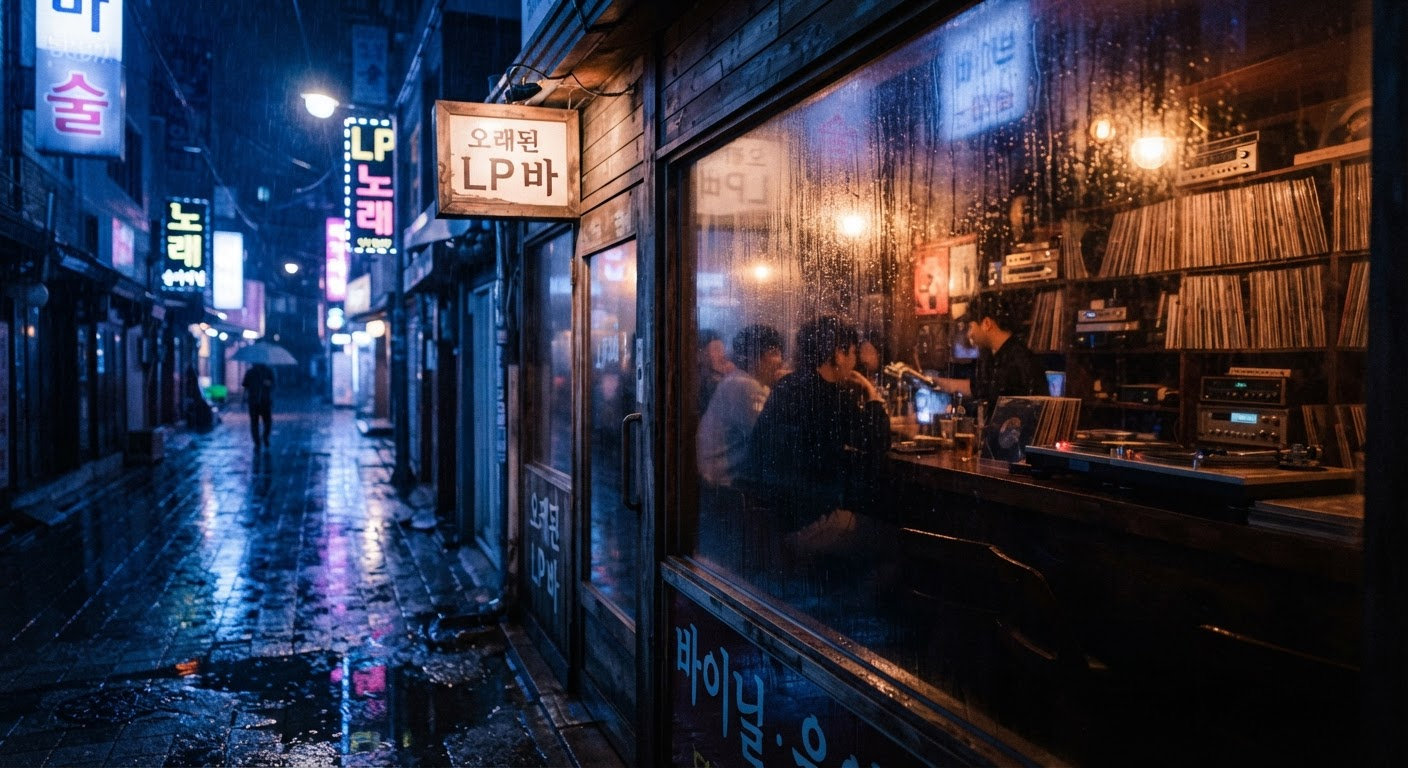

In [17]:
QUESTION = ("이 이미지를 두 문장으로 설명한다. 장소, 시간대, 눈에 띄는 사물을 포함하고, "
            "이미지에 없는 내용은 적지 않는다.")

display(Image("in_sample.jpg", width=480))
# print(vision("in_sample.jpg", QUESTION))

#### 단계 ④-b — 생성 호출 1회

    [paint] tokens prompt=51 output=1120
    [paint] out_generated.jpg image/jpeg 48287B 저장


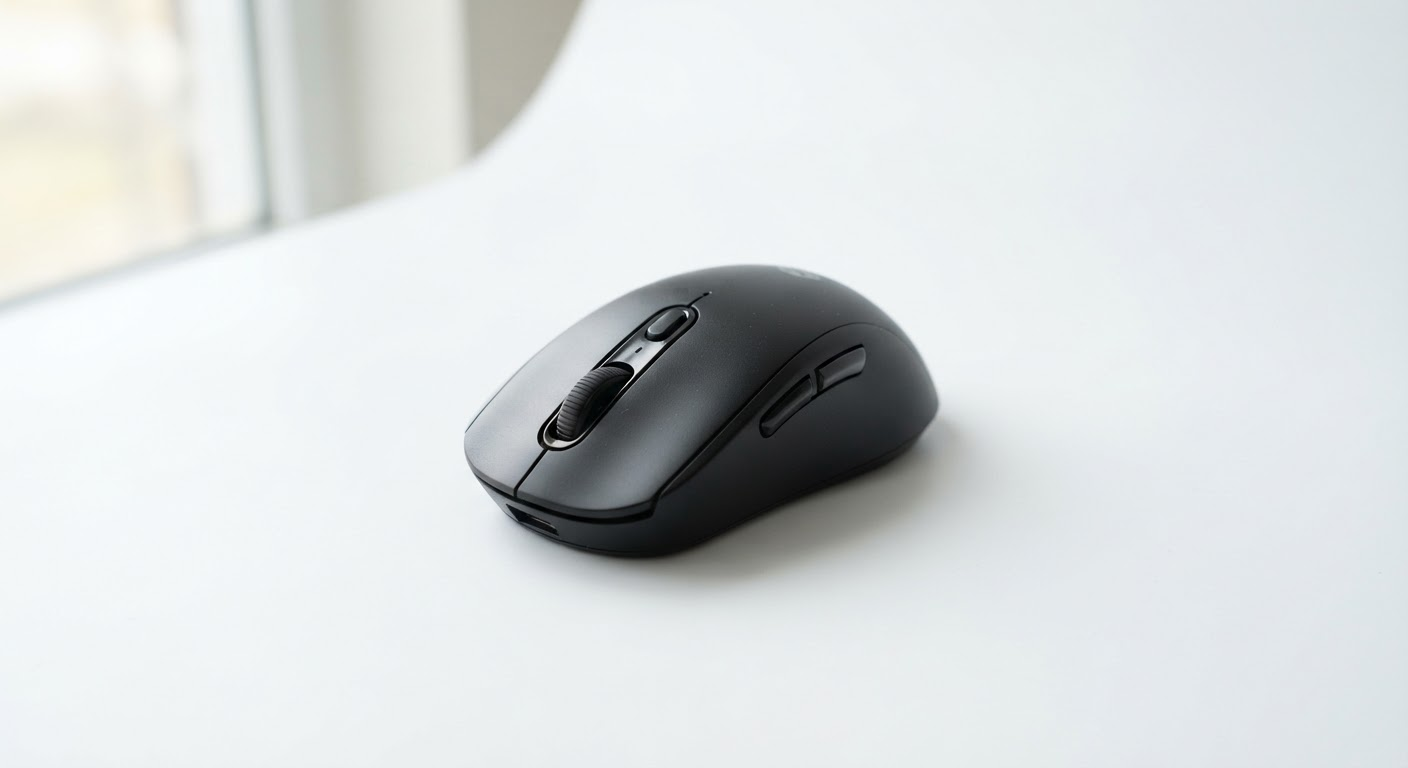

In [18]:
PROMPT = ("온라인 쇼핑몰 상품 안내 화면에 쓸 이미지. 흰 배경 위에 놓인 검정색 무선 마우스 하나, "
          "부드러운 자연광, 정면에서 약간 위를 내려다보는 화각, 글자는 넣지 않는다.")

paint(PROMPT, "out_generated.jpg")
display(Image("out_generated.jpg", width=480))

#### 단계 ④-c — 편집 호출 1회

    [edit] tokens prompt=1207 output=1208
    [edit] out_edited.jpg image/jpeg 186926B 저장


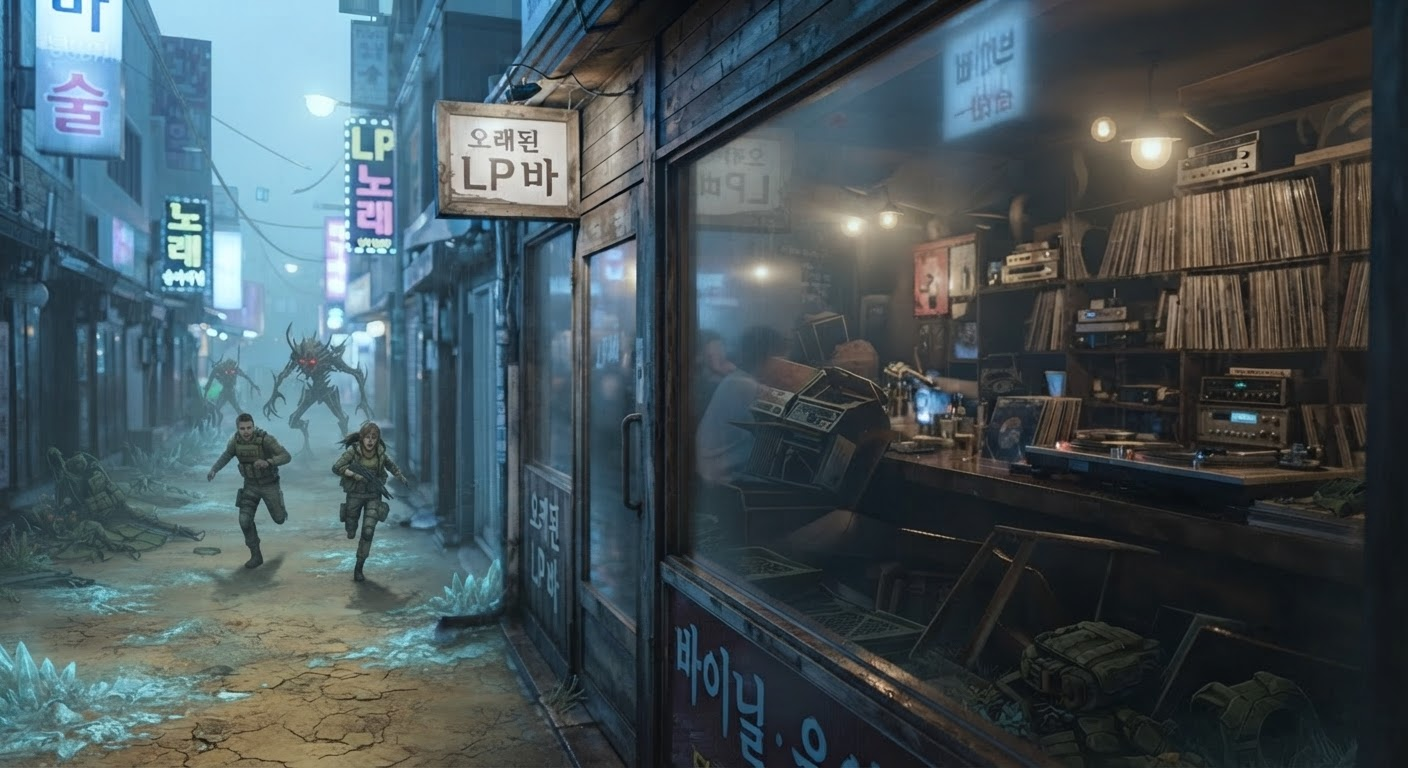

In [ ]:
INSTRUCTION = ("이 이미지의 구도와 사물은 그대로 두고, 소녀전선1 시대관인 붕괴액이 유출된 아포칼립스 세계관으로 만들어줘 "
               "젖은 바닥의 반사를 없애고 하늘빛의 자연광을 넣는다." "기행종도 두마리 길거리에 나타나게" "인간 하나는 기행종을 피해 도망가는것으로 해줘")

edit("in_sample.jpg", INSTRUCTION, "out_edited.jpg")
display(Image("out_edited.jpg", width=480))

#### 단계 ④-d — 비용 기록

In [10]:
# 단가(달러, 100만 토큰당) — 모델 안내 문서에 적힌 값
PRICE_INPUT = 0.25          # 입력 토큰
PRICE_OUTPUT_TEXT = 1.50    # 글 출력 토큰
PRICE_OUTPUT_IMAGE = 30.0   # 이미지 출력 토큰
IMAGE_TOKENS = 1120         # 이미지 1장의 출력 토큰 수

print(f"{'호출':<8}{'입력 토큰':>10}{'출력 토큰':>10}{'추정 비용($)':>14}")
total = 0.0
for u in USAGE:
    image_tokens = IMAGE_TOKENS if u["call"] in ("paint", "edit") else 0
    text_tokens = max(u["output"] - image_tokens, 0)
    cost = (u["prompt"] * PRICE_INPUT + text_tokens * PRICE_OUTPUT_TEXT
            + image_tokens * PRICE_OUTPUT_IMAGE) / 1_000_000
    total += cost
    print(f"{u['call']:<8}{u['prompt']:>10}{u['output']:>10}{cost:>14.4f}")
print(f"{'합계':<8}{'':>10}{'':>10}{total:>14.4f}")
print(f"호출 횟수: {len(USAGE)}회")

호출           입력 토큰     출력 토큰      추정 비용($)
vision        1154        77        0.0004
paint           51      1120        0.0336
edit          1165      1120        0.0339
합계                                  0.0679
호출 횟수: 3회


## 7. 실행 결과 확인

위 실행 결과에서 다음 네 가지를 확인합니다.

1. 단계 ④-a에서 `[vision]` 줄 뒤에 `in_sample.jpg`의 내용을 설명하는 글이 출력됩니다. 글의 내용이 함께 넣은 질문의 범위 안에 있습니다.
2. 단계 ④-b에서 `[paint]` 줄에 저장한 파일 이름 `out_generated.jpg`와 바이트 수가 출력되고, 그 아래에 생성된 이미지가 표시됩니다.
3. 단계 ④-c에서 `[edit]` 줄에 저장한 파일 이름 `out_edited.jpg`가 출력되고, 표시된 이미지가 원본 `in_sample.jpg`의 구도를 유지한 채 지시문대로 바뀌어 있습니다.
4. 단계 ④-d의 표에 호출 세 줄(vision·paint·edit)이 있고, 줄마다 입력 토큰·출력 토큰·추정 비용이 적혀 있으며, 마지막 줄이 합계입니다. 이미지를 돌려준 두 호출의 출력 토큰이 글만 돌려준 호출보다 큽니다.